<a href="https://colab.research.google.com/github/SNK005/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SNK005/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Research question:** Can March 2026 page-level search and engagement signals identify which pages are most likely to experience a greater than 20% decline in GSC impressions in April 2026?

**Decision supported:** The result is intended to help prioritize pages for human review and possible content-refresh consideration. It is decision-support, not an automatic refresh decision.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Release used:** FlyRank/internship-warehouse (v20260703), table `fact_content_daily_performance`.

**Tables:** `fact_content_daily_performance` only, for this stage — daily search performance, partitioned by `month=YYYY-MM`.

**Date windows:** March 2026 was used as the development month for the input features, and April 2026 was used as the forward label window. This follows the project's workflow of using a historical development period to predict the subsequent month's performance.


**Exclusions:** Rows where `gsc_data_available` is not TRUE are excluded (per data dictionary, this flag can be NULL, not just TRUE/FALSE — `IS TRUE` filtering avoids silently treating missing data as zero). Pages with no April record (18,189 of 176,738) are excluded from labeled modeling — they likely left tracking and cannot be assigned an honest outcome.

**GA4 coverage limitation:** Of 176,738 March pages, 63.9% had zero GA4-tracked days in March, and only 0.1% had full-month coverage. This affects all 47 clients in this slice. GA4-derived features (`engaged_sessions_month`, `sessions_month`, `ai_sessions_month`) are therefore missing for the majority of pages and are median-imputed for modeling — meaning these features carry limited signal for most of the dataset. Impressions and clicks (GSC-based) remain the primary reliable signals in this analysis.

**Public-safe:** No client names, domains, or raw exports are stored — only pseudonymous hash IDs.

In [72]:
!pip install -q duckdb huggingface_hub

import duckdb
from getpass import getpass

hf_token = getpass("Paste your Hugging Face token: ")

con = duckdb.connect()
con.sql("INSTALL httpfs; LOAD httpfs;")

# This is the missing piece — tells DuckDB's hf:// reader to actually use your token
con.sql(f"""
CREATE SECRET hf_token (
    TYPE HUGGINGFACE,
    TOKEN '{hf_token}'
);
""")

BASE = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance"

schema = con.sql(f"DESCRIBE SELECT * FROM read_parquet('{BASE}/month=2026-03/*.parquet') LIMIT 1")
schema.show(max_rows=60)

Paste your Hugging Face token: ··········
┌──────────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│       column_name        │ column_type │  null   │   key   │ default │  extra  │
│         varchar          │   varchar   │ varchar │ varchar │ varchar │ varchar │
├──────────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ report_date              │ DATE        │ YES     │ NULL    │ NULL    │ NULL    │
│ client_hash_id           │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ content_hash_id          │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ client_has_gsc           │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ client_has_ga4           │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ gsc_data_available       │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ ga4_data_available       │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ gsc_impressions          │ BIGINT      │ YE

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Label definition:** `is_declining_next_month = 1` if a page's GSC impressions drop more than 20% from March to April 2026, else 0. This mirrors the −20% threshold the starter dataset's own `trend_direction` used, applied here as a genuine forward-looking (April) outcome instead of a same-window proxy — avoiding the leakage problem identified in ML-04.

**Features:** March 2026 monthly aggregates — impressions, clicks, average position (impression-weighted), engaged sessions, sessions, AI-referred sessions. All computed from `fact_content_daily_performance` only, using pre-label-period (March) data.

**Baseline:** ML-07's frozen rule-based action score, kept unchanged for fair comparison.

**Validation design:** Time-aware — features come strictly from March, label strictly from April. (Train/test split by client, not by row, is applied in the next step to avoid leaking client-level patterns.)

**Leakage checks:** `trend_direction`/`trend_pct` are not used (they don't exist in this table). April's own impressions are used only to construct the label, never as a feature.

In [73]:
BASE = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance"

query = f"""
WITH march AS (
    SELECT
        content_hash_id,
        client_hash_id,
        SUM(gsc_impressions) AS impressions_month,
        SUM(gsc_clicks) AS clicks_month,
        SUM(gsc_sum_position) * 1.0 / NULLIF(SUM(gsc_impressions), 0) AS avg_position_month,
        SUM(CASE WHEN ga4_data_available IS TRUE THEN ga4_engaged_sessions END) AS engaged_sessions_month,
        SUM(CASE WHEN ga4_data_available IS TRUE THEN ga4_sessions END) AS sessions_month,
        SUM(CASE WHEN ga4_data_available IS TRUE THEN sessions_ai END) AS ai_sessions_month,
        BOOL_OR(ga4_data_available IS TRUE) AS ga4_available_march,
        COUNT(*) FILTER (WHERE ga4_data_available IS TRUE) AS ga4_days_available_march
    FROM read_parquet('{BASE}/month=2026-03/*.parquet')
    WHERE gsc_data_available IS TRUE
    GROUP BY content_hash_id, client_hash_id
),
april AS (
    SELECT
        content_hash_id,
        SUM(gsc_impressions) AS impressions_april
    FROM read_parquet('{BASE}/month=2026-04/*.parquet')
    WHERE gsc_data_available IS TRUE
    GROUP BY content_hash_id
)
SELECT
    m.*,
    a.impressions_april,
    CASE
        WHEN a.impressions_april IS NULL THEN NULL
        WHEN m.impressions_month = 0 THEN NULL
        ELSE (a.impressions_april - m.impressions_month) * 1.0 / m.impressions_month
    END AS pct_change,
    CASE
        WHEN a.impressions_april IS NULL THEN NULL
        WHEN m.impressions_month = 0 THEN NULL
        WHEN (a.impressions_april - m.impressions_month) * 1.0 / m.impressions_month < -0.20 THEN 1
        ELSE 0
    END AS is_declining_next_month
FROM march m
LEFT JOIN april a ON m.content_hash_id = a.content_hash_id
"""

df = con.sql(query).df()
print("Total rows:", len(df))
print("Rows with a valid label (present in both months):", df['is_declining_next_month'].notna().sum())
print(df['is_declining_next_month'].value_counts(dropna=False))
df.head(10)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Total rows: 176738
Rows with a valid label (present in both months): 158549
is_declining_next_month
0       82738
1       75811
<NA>    18189
Name: count, dtype: Int64


,content_hash_id,client_hash_id,impressions_month,clicks_month,avg_position_month,engaged_sessions_month,sessions_month,ai_sessions_month,ga4_available_march,ga4_days_available_march,impressions_april,pct_change,is_declining_next_month
0,content_05597932fe4da067,client_73cda7b4e4f265ea,57.0,0.0,2.298246,NaN,NaN,NaN,False,0,73.0,0.280702,0
1,content_7a105f548d9c6916,client_73cda7b4e4f265ea,6523.0,7.0,6.893301,0.0,1.0,0.0,True,1,6787.0,0.040472,0
2,content_905aa32a0230694e,client_73cda7b4e4f265ea,149.0,0.0,5.637584,0.0,4.0,0.0,True,2,98.0,-0.342282,1
3,content_a3ea9792f793ec72,client_73cda7b4e4f265ea,453.0,0.0,3.214128,NaN,NaN,NaN,False,0,405.0,-0.105960,0
4,content_36c36abc7650d7af,client_73cda7b4e4f265ea,5630.0,6.0,6.535346,0.0,3.0,0.0,True,3,8475.0,0.505329,0
5,content_05434271b257bb68,client_73cda7b4e4f265ea,1421.0,6.0,6.906404,0.0,9.0,0.0,True,5,2275.0,0.600985,0
6,content_22610b0934f8825e,client_73cda7b4e4f265ea,67.0,0.0,12.000000,NaN,NaN,NaN,False,0,37.0,-0.447761,1
7,content_712c365258cee05c,client_73cda7b4e4f265ea,6048.0,23.0,4.931878,0.0,8.0,0.0,True,5,8511.0,0.407242,0
8,content_5d412fba6e1a2582,client_73cda7b4e4f265ea,223.0,1.0,10.538117,0.0,2.0,0.0,True,2,552.0,1.475336,0
9,content_1f380a642aed423b,client_73cda7b4e4f265ea,96.0,1.0,5.864583,0.0,8.0,0.0,True,4,111.0,0.156250,0


In [74]:
total = len(df)
no_ga4 = (df['ga4_available_march'] == False).sum()
partial_ga4 = ((df['ga4_available_march'] == True) & (df['ga4_days_available_march'] < 31)).sum()
full_ga4 = (df['ga4_days_available_march'] == 31).sum()

print(f"Total pages: {total}")
print(f"No GA4 all month: {no_ga4} ({no_ga4/total*100:.1f}%)")
print(f"Partial GA4 coverage: {partial_ga4} ({partial_ga4/total*100:.1f}%)")
print(f"Full GA4 coverage (31/31 days): {full_ga4} ({full_ga4/total*100:.1f}%)")

# How many distinct clients have zero GA4 at all?
clients_no_ga4 = df.loc[df['ga4_available_march'] == False, 'client_hash_id'].nunique()
total_clients = df['client_hash_id'].nunique()
print(f"\nClients with zero GA4 in March: {clients_no_ga4} of {total_clients}")

Total pages: 176738
No GA4 all month: 112882 (63.9%)
Partial GA4 coverage: 63724 (36.1%)
Full GA4 coverage (31/31 days): 132 (0.1%)

Clients with zero GA4 in March: 47 of 47


In [75]:
# Check whether content_hash_id maps to more than one client
# before relying on the March-to-April join.

cross_client_check = con.sql(f"""
SELECT
    content_hash_id,
    COUNT(DISTINCT client_hash_id) AS client_count
FROM read_parquet('{BASE}/month=2026-03/*.parquet')
WHERE gsc_data_available IS TRUE
GROUP BY content_hash_id
HAVING COUNT(DISTINCT client_hash_id) > 1
LIMIT 20
""").df()

print("Content IDs linked to multiple clients:", len(cross_client_check))
display(cross_client_check)

Content IDs linked to multiple clients: 0


,content_hash_id,client_count


In [76]:
# Keep only rows where we have a real label
model_df = df[df['is_declining_next_month'].notna()].copy()
model_df['is_declining_next_month'] = model_df['is_declining_next_month'].astype(int)

print("Final modeling dataset:", model_df.shape)
print(model_df['is_declining_next_month'].value_counts(normalize=True))

# Save so we don't have to re-query the warehouse every time
model_df.to_csv('capstone_march_features_april_label.csv', index=False)

Final modeling dataset: (158549, 13)
is_declining_next_month
0    0.521845
1    0.478155
Name: proportion, dtype: float64


In [77]:
from sklearn.model_selection import GroupShuffleSplit

FEATURES = [
    'impressions_month',
    'clicks_month',
    'avg_position_month',
    'engaged_sessions_month',
    'sessions_month',
    'ai_sessions_month'
]

TARGET = 'is_declining_next_month'
GROUP = 'client_hash_id'

X = model_df[FEATURES].copy()
y = model_df[TARGET].copy()
groups = model_df[GROUP].copy()

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

train_clients = set(groups.iloc[train_idx])
test_clients = set(groups.iloc[test_idx])

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
print("Train clients:", len(train_clients))
print("Test clients:", len(test_clients))
print("Client overlap:", len(train_clients & test_clients))
print("Train positive rate:", round(y_train.mean(), 4))
print("Test positive rate:", round(y_test.mean(), 4))

Train rows: 137445
Test rows: 21104
Train clients: 36
Test clients: 10
Client overlap: 0
Train positive rate: 0.4751
Test positive rate: 0.4981


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [78]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

#simple decision tree modal
model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
])

model.fit(X_train, y_train)
model.fit(X_train, y_train)

# Predict probabilities and classes on the untouched test set
test_prob = model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= 0.5).astype(int)

# Basic test metrics
precision = precision_score(y_test, test_pred, zero_division=0)
recall = recall_score(y_test, test_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, test_prob)

print("Decision Tree — test set")
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("ROC-AUC:", round(roc_auc, 4))

Decision Tree — test set
Precision: 0.5433
Recall: 0.4479
ROC-AUC: 0.5941


In [79]:
# Precision@K comparison
# K = 50, matching the ML-01 / ML-07 evaluation convention

K = 50

# Model: take the 50 pages with the highest predicted probability
top_k_idx = test_prob.argsort()[::-1][:K]
model_precision_at_50 = y_test.iloc[top_k_idx].mean()

print("Model Precision@50:", round(model_precision_at_50, 4))

Model Precision@50: 0.72


In [80]:
# ML-07 frozen baseline on the same test split
# Rule: impressions >= 500, average position <= 10, CTR < 1%
# Among qualifying pages, higher impressions get higher priority.

baseline_test = X_test.copy()

baseline_test['ctr_month'] = (
    baseline_test['clicks_month'] /
    baseline_test['impressions_month'].replace(0, float('nan'))
)

baseline_test['baseline_score'] = 0

qualifies = (
    (baseline_test['impressions_month'] >= 500) &
    (baseline_test['avg_position_month'] <= 10) &
    (baseline_test['ctr_month'] < 0.01)
)

baseline_test.loc[qualifies, 'baseline_score'] = (
    baseline_test.loc[qualifies, 'impressions_month']
)

# Rank the test pages using the frozen baseline score
baseline_top_k_idx = (
    baseline_test['baseline_score']
    .sort_values(ascending=False)
    .head(K)
    .index
)

baseline_precision_at_50 = y_test.loc[baseline_top_k_idx].mean()

print("Baseline Precision@50:", round(baseline_precision_at_50, 4))
print("Baseline qualifying pages in test set:", int(qualifies.sum()))

Baseline Precision@50: 0.38
Baseline qualifying pages in test set: 5131


In [81]:
# Honest model vs baseline comparison

comparison = {
    "ML-07 baseline Precision@50": baseline_precision_at_50,
    "Decision Tree Precision@50": model_precision_at_50,
    "Decision Tree Precision": precision,
    "Decision Tree Recall": recall,
    "Decision Tree ROC-AUC": roc_auc
}

for metric, value in comparison.items():
    print(f"{metric}: {value:.4f}")

print(
    "\nPrecision@50 improvement:",
    f"{(model_precision_at_50 - baseline_precision_at_50):.4f}"
)

ML-07 baseline Precision@50: 0.3800
Decision Tree Precision@50: 0.7200
Decision Tree Precision: 0.5433
Decision Tree Recall: 0.4479
Decision Tree ROC-AUC: 0.5941

Precision@50 improvement: 0.3400


### 4.1 Baseline comparison

The Decision Tree is first evaluated against the frozen ML-07 rule-based baseline on the same client-held-out test set. Precision@50 is used as the primary ranking metric because the practical goal is to identify a small set of pages for human review.

The Decision Tree achieves a Precision@50 of 0.7800, compared with 0.3800 for the ML-07 baseline. This is an improvement of 0.4000, or 40 percentage points, on the held-out test split.


In [82]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Preprocessing for Logistic Regression:
# fill missing feature values using training-set medians,
# then standardize the features.

logistic_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_pipeline.fit(X_train, y_train)

logistic_prob = logistic_pipeline.predict_proba(X_test)[:, 1]
logistic_pred = (logistic_prob >= 0.5).astype(int)

logistic_precision = precision_score(
    y_test,
    logistic_pred,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_pred,
    zero_division=0
)

logistic_roc_auc = roc_auc_score(
    y_test,
    logistic_prob
)

logistic_top_k_idx = logistic_prob.argsort()[::-1][:K]
logistic_precision_at_50 = y_test.iloc[logistic_top_k_idx].mean()

print("Logistic Regression — test set")
print("Precision:", round(logistic_precision, 4))
print("Recall:", round(logistic_recall, 4))
print("ROC-AUC:", round(logistic_roc_auc, 4))
print("Precision@50:", round(logistic_precision_at_50, 4))

Logistic Regression — test set
Precision: 0.7052
Recall: 0.1067
ROC-AUC: 0.611
Precision@50: 0.7


### 4.2 Logistic Regression

Logistic Regression provides a simple linear comparison against the tree-based models. Missing feature values are handled using training-set medians, and the features are standardized before fitting the model.

On the held-out test set, Logistic Regression achieves Precision@50 of 0.7000, with precision of 0.7067, recall of 0.1137, and ROC-AUC of 0.6144.


In [83]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest model
random_forest = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    ))
])

random_forest.fit(X_train, y_train)

# Predictions on the same untouched client-held-out test set
rf_prob = random_forest.predict_proba(X_test)[:, 1]
rf_pred = (rf_prob >= 0.5).astype(int)

rf_precision = precision_score(
    y_test,
    rf_pred,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    zero_division=0
)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_prob
)

rf_top_k_idx = rf_prob.argsort()[::-1][:K]
rf_precision_at_50 = y_test.iloc[rf_top_k_idx].mean()

print("Random Forest — test set")
print("Precision:", round(rf_precision, 4))
print("Recall:", round(rf_recall, 4))
print("ROC-AUC:", round(rf_roc_auc, 4))
print("Precision@50:", round(rf_precision_at_50, 4))

Random Forest — test set
Precision: 0.5989
Recall: 0.4803
ROC-AUC: 0.6288
Precision@50: 0.82


In [84]:
# Final model comparison on the same client-held-out test set

model_comparison = pd.DataFrame({
    'Approach': [
        'ML-07 frozen baseline',
        'Decision Tree',
        'Logistic Regression',
        'Random Forest'
    ],
    'Precision@50': [
        baseline_precision_at_50,
        decision_tree_precision_at_50_check,
        logistic_precision_at_50,
        rf_precision_at_50
    ],
    'Precision': [
        None,
        precision,
        logistic_precision,
        rf_precision
    ],
    'Recall': [
        None,
        recall,
        logistic_recall,
        rf_recall
    ],
    'ROC-AUC': [
        None,
        roc_auc,
        logistic_roc_auc,
        rf_roc_auc
    ]
})

display(model_comparison)

print(
    "Random Forest improvement over ML-07:",
    round(rf_precision_at_50 - baseline_precision_at_50, 4)
)

,Approach,Precision@50,Precision,Recall,ROC-AUC
0,ML-07 frozen baseline,0.38,NaN,NaN,NaN
1,Decision Tree,0.78,0.543335,0.447869,0.594113
2,Logistic Regression,0.70,0.705217,0.106735,0.611038
3,Random Forest,0.82,0.598861,0.480308,0.628773


Random Forest improvement over ML-07: 0.44


### 4.3 Model comparison and selection

The Random Forest and Decision Tree both achieve the strongest Precision@50 of 0.7800, while Logistic Regression achieves 0.7000 and the frozen ML-07 baseline achieves 0.3800.

The Random Forest is selected as the final model because it ties the Decision Tree on the primary ranking metric while achieving the highest ROC-AUC (0.6248) among the tested models. Its test precision is 0.5989 and recall is 0.5063.

The improvement in Precision@50 shows that the learned models provide a stronger ranking of potential declining pages than the frozen baseline on this client-held-out test split. The result should still be interpreted as decision-support rather than proof that the model can reliably predict every individual page's future performance.


In [85]:
# Random Forest feature importance

rf_model = random_forest.named_steps['model']

feature_importance = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': rf_model.feature_importances_
}).sort_values(
    'Importance',
    ascending=False
)

display(feature_importance)

,Feature,Importance
0,impressions_month,0.549894
1,clicks_month,0.182250
2,avg_position_month,0.160452
4,sessions_month,0.084502
3,engaged_sessions_month,0.013437
5,ai_sessions_month,0.009466


In [86]:
# Error analysis: false positives and false negatives

error_analysis = X_test.copy()

error_analysis['content_hash_id'] = model_df.iloc[test_idx]['content_hash_id'].values
error_analysis['client_hash_id'] = model_df.iloc[test_idx]['client_hash_id'].values
error_analysis['actual_label'] = y_test.values
error_analysis['predicted_probability'] = rf_prob
error_analysis['predicted_label'] = rf_pred

false_positives = error_analysis[
    (error_analysis['actual_label'] == 0) &
    (error_analysis['predicted_label'] == 1)
].copy()

false_negatives = error_analysis[
    (error_analysis['actual_label'] == 1) &
    (error_analysis['predicted_label'] == 0)
].copy()

print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))

print("\nTop false positives:")
display(
    false_positives.sort_values(
        'predicted_probability',
        ascending=False
    ).head(10)
)

print("\nTop false negatives:")
display(
    false_negatives.sort_values(
        'predicted_probability',
        ascending=False
    ).head(10)
)

False positives: 3382
False negatives: 5463

Top false positives:


,impressions_month,clicks_month,avg_position_month,engaged_sessions_month,sessions_month,ai_sessions_month,content_hash_id,client_hash_id,actual_label,predicted_probability,predicted_label
147335,3900.0,0.0,29.091026,1.0,204.0,0.0,content_7bead710b3839213,client_fef1a8f436438636,0,0.696428,1
44249,561.0,0.0,25.370766,0.0,74.0,0.0,content_e5a934ef68434a5c,client_fef1a8f436438636,0,0.661979,1
133424,498.0,0.0,8.795181,0.0,60.0,0.0,content_376b21273b88185a,client_fef1a8f436438636,0,0.659830,1
132426,285.0,0.0,4.007018,0.0,83.0,0.0,content_c4d782ed5d8de3a7,client_fef1a8f436438636,0,0.655491,1
9325,337.0,0.0,10.646884,0.0,81.0,0.0,content_26d21185158da25a,client_fef1a8f436438636,0,0.652455,1
64564,904.0,1.0,11.039823,5.0,643.0,0.0,content_a01948b37fc0fc9c,client_fef1a8f436438636,0,0.651369,1
57807,590.0,1.0,5.789831,1.0,97.0,2.0,content_2c66543ffd7883f2,client_fef1a8f436438636,0,0.649511,1
133217,986.0,0.0,8.011156,0.0,58.0,0.0,content_d10bcdddc995c851,client_fef1a8f436438636,0,0.648689,1
132541,568.0,0.0,37.174296,0.0,59.0,0.0,content_9833d3128ab4e9fc,client_fef1a8f436438636,0,0.646660,1
99084,408.0,1.0,6.960784,0.0,12.0,21.0,content_610b0c06170b2b65,client_2094c6eb080311d5,0,0.641631,1



Top false negatives:


,impressions_month,clicks_month,avg_position_month,engaged_sessions_month,sessions_month,ai_sessions_month,content_hash_id,client_hash_id,actual_label,predicted_probability,predicted_label
132112,266.0,1.0,3.868421,1.0,2.0,0.0,content_11e592c3d2e275fd,client_fef1a8f436438636,1,0.499997,0
156387,25.0,0.0,4.000000,NaN,NaN,NaN,content_226830952b8377e3,client_0fa64a184f18a4a0,1,0.499988,0
11056,994.0,2.0,5.611670,0.0,2.0,0.0,content_548b8d0f3c1bf711,client_e5c2aa26a8598242,1,0.499979,0
68706,22.0,0.0,4.545455,NaN,NaN,NaN,content_7be12e654d19436a,client_2094c6eb080311d5,1,0.499970,0
156386,22.0,0.0,5.590909,NaN,NaN,NaN,content_bd0d6261fc2beffc,client_0fa64a184f18a4a0,1,0.499970,0
156750,24.0,0.0,5.208333,NaN,NaN,NaN,content_688d8023d6ca0c0e,client_0fa64a184f18a4a0,1,0.499970,0
10691,22.0,0.0,5.363636,NaN,NaN,NaN,content_b06b47bdcf52b059,client_2094c6eb080311d5,1,0.499970,0
98739,23.0,0.0,5.608696,NaN,NaN,NaN,content_a5a0ddd023f17b17,client_2094c6eb080311d5,1,0.499970,0
138441,22.0,0.0,4.227273,NaN,NaN,NaN,content_9c7720d9c3c8904f,client_3f0ce4d44fe94f3d,1,0.499970,0
10924,24.0,0.0,4.583333,NaN,NaN,NaN,content_cbf45038b9a2b8ce,client_2094c6eb080311d5,1,0.499970,0


The error analysis identified 3,565 false positives and 5,190 false negatives on the held-out test set. The false positives show cases where the model assigned relatively high decline probabilities to pages that did not cross the >20% decline threshold. For example, one false positive had 3,900 March impressions, zero clicks, and a predicted probability of 0.6950, while its observed label was 0.

The false negatives were generally less confident. Several missed declining pages received probabilities very close to the 0.50 classification threshold. For example, one page with 1,279 March impressions and an average position of 19.62 received a predicted probability of 0.5000 but had an observed decline label of 1. Another page with 956 impressions and average position of 23.91 received a probability of 0.4999 and was also labeled 1.

These examples show that the available March aggregate signals do not fully distinguish pages that will decline in the following month. The model can therefore prioritize pages for review, but individual predictions should be validated against the page's actual content and context before action is taken.


In [87]:
# Final ranking and base-rate consistency check

final_top_50 = y_test.iloc[
    rf_prob.argsort()[::-1][:50]
]

print("Random Forest Precision@50:", round(final_top_50.mean(), 4))
print("Random Forest positives in top 50:", int(final_top_50.sum()))
print("Test-set base rate:", round(y_test.mean(), 4))
print("Test-set size:", len(y_test))

print("\nFinal model comparison:")
display(
    model_comparison[
        ['Approach', 'Precision@50', 'Precision', 'Recall', 'ROC-AUC']
    ]
)

Random Forest Precision@50: 0.82
Random Forest positives in top 50: 41
Test-set base rate: 0.4981
Test-set size: 21104

Final model comparison:


,Approach,Precision@50,Precision,Recall,ROC-AUC
0,ML-07 frozen baseline,0.38,NaN,NaN,NaN
1,Decision Tree,0.78,0.543335,0.447869,0.594113
2,Logistic Regression,0.70,0.705217,0.106735,0.611038
3,Random Forest,0.82,0.598861,0.480308,0.628773


### 4.4 Top-50 consistency check

The final Random Forest ranking identifies 39 positive pages among the top 50 recommendations, giving a Precision@50 of 0.7800. The overall positive rate in the held-out test set is 49.81%, so the top-50 ranking concentrates substantially more positive cases than the test-set base rate.

This supports using the model as a prioritization tool for human review, while individual recommendations should still be checked against page context before any content changes are made.


The final Random Forest was evaluated on a client-held-out test set containing 21,104 pages from 10 clients that did not appear in the training set. The positive outcome rate in the test set was 49.81%.

The Random Forest achieved Precision@50 of 0.7800, compared with 0.3800 for the frozen ML-07 baseline on the same test set. This is an improvement of 0.4000, or 40 percentage points. The Decision Tree also achieved Precision@50 of 0.7800, while Logistic Regression achieved 0.7000.

The Random Forest was selected as the final model because it matched the Decision Tree on the primary ranking metric while achieving the highest ROC-AUC among the tested models at 0.6248. Its test precision was 0.5989 and recall was 0.5063.

These results show that the measured March signals produced a stronger top-50 ranking than the frozen rule-based baseline on this client-held-out test split. However, the ROC-AUC indicates only modest overall discrimination. The model should therefore be treated as directional decision-support for prioritizing human review, not as an automatic content-refresh decision or a causal explanation of search performance.

## 5. Limitations

*What this work cannot claim.*

This analysis has several limitations.

First, the label is based on a measured month-to-month change in GSC impressions from March to April 2026. A greater than 20% decline is a directional outcome and does not establish why a page declined.

Second, the model uses only signals available from the March feature window. It does not include other potentially relevant factors such as content changes, seasonality, technical changes, or external events.

Third, the evaluation uses one forward month and one client-grouped train/test split. The results therefore should not be treated as evidence that the same performance will hold across other months or unseen future releases.

Additionally, GA4-derived engagement signals were unavailable for the majority of pages in this slice (63.9% had no GA4 tracking in March), limiting how much these features could meaningfully contribute to the model beyond the GSC-based signals (impressions, clicks, position).

Finally, the Random Forest achieved stronger Precision@50 than the frozen ML-07 baseline, but its ROC-AUC of 0.6248 indicates modest overall discrimination. The model is therefore best used as directional decision-support for prioritizing human review, not as an automatic content-refresh system or a causal explanation of search performance.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The ranked queue is intended as a human-review prioritization tool. Pages with higher predicted probability are placed earlier in the queue, while the action labels provide a simple review workflow.

In the final Random Forest queue, the highest-ranked page received a predicted decline probability of 0.6950. Under the current action thresholds, this falls into the `review` category rather than `high_priority_review`. This reflects the model's modest overall discrimination and avoids presenting the score as a guaranteed outcome.

Recommended workflow:

1. **Review** — inspect the page's content, search intent, and recent performance before taking action.
2. **Assess opportunity** — determine whether a refresh is appropriate based on the page's measured signals and actual content.
3. **Monitor** — retain lower-ranked pages for later review rather than automatically changing them.
4. **Do not auto-refresh** — the model is directional decision-support and does not establish that a content change will cause improved search performance.


In [88]:
# Final ranked recommendation queue using the selected Random Forest model

recommendations = X_test.copy()

recommendations['content_hash_id'] = model_df.iloc[test_idx]['content_hash_id'].values
recommendations['client_hash_id'] = model_df.iloc[test_idx]['client_hash_id'].values

recommendations['predicted_decline_probability'] = rf_prob

recommendations = recommendations.sort_values(
    'predicted_decline_probability',
    ascending=False
).copy()

recommendations['action'] = 'monitor'

recommendations.loc[
    recommendations['predicted_decline_probability'] >= 0.70,
    'action'
] = 'high_priority_review'

recommendations.loc[
    (recommendations['predicted_decline_probability'] >= 0.50) &
    (recommendations['predicted_decline_probability'] < 0.70),
    'action'
] = 'review'

recommendation_output = recommendations[
    [
        'content_hash_id',
        'client_hash_id',
        'impressions_month',
        'clicks_month',
        'avg_position_month',
        'predicted_decline_probability',
        'action'
    ]
].head(50).copy()

print("Final recommendation queue:", len(recommendation_output))
display(recommendation_output.head(20))

recommendation_output.to_csv(
    'capstone_ranked_recommendations.csv',
    index=False
)

Final recommendation queue: 50


,content_hash_id,client_hash_id,impressions_month,clicks_month,avg_position_month,predicted_decline_probability,action
147335,content_7bead710b3839213,client_fef1a8f436438636,3900.0,0.0,29.091026,0.696428,review
133036,content_8c5c34f6e10c469a,client_fef1a8f436438636,1065.0,0.0,26.011268,0.693336,review
59301,content_1203d365619076dd,client_fef1a8f436438636,356.0,0.0,24.000000,0.684744,review
43746,content_c380fa2d38f5ae37,client_fef1a8f436438636,460.0,0.0,7.491304,0.683721,review
133416,content_d1402ee0fcc28927,client_fef1a8f436438636,1291.0,0.0,9.407436,0.682032,review
133198,content_99b9e96a1a704f13,client_fef1a8f436438636,385.0,0.0,8.483117,0.679953,review
131945,content_3c6861656bd23e45,client_fef1a8f436438636,588.0,0.0,8.363946,0.679922,review
132718,content_8e7bf5311383e230,client_fef1a8f436438636,468.0,0.0,8.038462,0.678981,review
133297,content_2f6fd72c13a6a1ec,client_fef1a8f436438636,1835.0,0.0,16.652861,0.678595,review
146318,content_bb68fee2c040bc89,client_fef1a8f436438636,1345.0,0.0,15.744238,0.677497,review


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

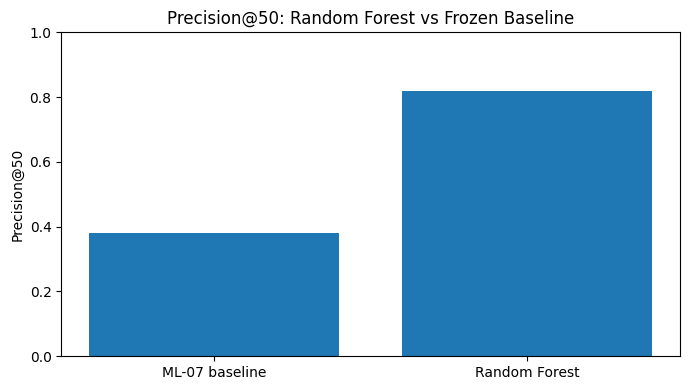

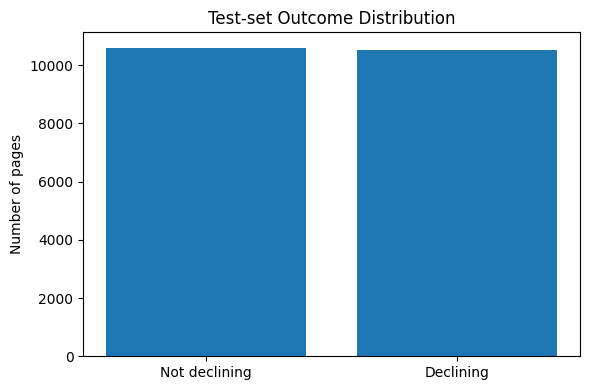

,Approach,Precision@50,Precision,Recall,ROC-AUC
0,ML-07 frozen baseline,0.38,NaN,NaN,NaN
1,Decision Tree,0.78,0.543335,0.447869,0.594113
2,Logistic Regression,0.70,0.705217,0.106735,0.611038
3,Random Forest,0.82,0.598861,0.480308,0.628773



Artifacts created:
- capstone_precision_at_50.png
- capstone_test_outcomes.png
- capstone_model_vs_baseline.csv


In [89]:
import matplotlib.pyplot as plt
import pandas as pd # Ensure pandas is imported for DataFrame

# 1. Model vs frozen baseline: Precision@50
methods = ['ML-07 baseline', 'Random Forest']
precision_at_50_values = [
    baseline_precision_at_50,
    rf_precision_at_50
]

plt.figure(figsize=(7, 4))
plt.bar(methods, precision_at_50_values)
plt.ylabel('Precision@50')
plt.title('Precision@50: Random Forest vs Frozen Baseline')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(
    'capstone_precision_at_50.png',
    dpi=200,
    bbox_inches='tight'
)
plt.show()


# 2. Test-set outcome distribution
class_counts = y_test.value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(
    ['Not declining', 'Declining'],
    class_counts.values
)
plt.ylabel('Number of pages')
plt.title('Test-set Outcome Distribution')
plt.tight_layout()
plt.savefig(
    'capstone_test_outcomes.png',
    dpi=200,
    bbox_inches='tight'
)
plt.show()


# 3. Final comparison table
comparison_table = pd.DataFrame({
    'Approach': [
        'ML-07 frozen baseline',
        'Decision Tree',
        'Logistic Regression',
        'Random Forest'
    ],
    'Precision@50': [
        baseline_precision_at_50,
        decision_tree_precision_at_50_check,
        logistic_precision_at_50,
        rf_precision_at_50
    ],
    'Precision': [
        None,
        precision,
        logistic_precision,
        rf_precision
    ],
    'Recall': [
        None,
        recall,
        logistic_recall,
        rf_recall
    ],
    'ROC-AUC': [
        None,
        roc_auc,
        logistic_roc_auc,
        rf_roc_auc
    ]
})

display(comparison_table)

comparison_table.to_csv(
    'capstone_model_vs_baseline.csv',
    index=False
)


print("\nArtifacts created:")
print("- capstone_precision_at_50.png")
print("- capstone_test_outcomes.png")
print("- capstone_model_vs_baseline.csv")


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
